In [2]:
# Ignore a bunch of deprecation warnings
import warnings
warnings.filterwarnings("ignore")

import copy
import os
import time

import crepe
import ddsp
import ddsp.training
from ddsp.training.postprocessing import (
    detect_notes, fit_quantile_transform
)
from ddsp.training import (data, decoders, encoders, models, preprocessing, 
                           train_util, trainers)
import gin
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pickle
import tensorflow.compat.v2 as tf
import tensorflow_datasets as tfds

print('Done!')
     

2025-05-11 00:18:58.706349: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-11 00:18:58.848892: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-05-11 00:18:58.848922: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2025-05-11 00:19:00.208735: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2025-

Done!


In [3]:
# Plot spectrograms
def plot_spectrogram(waveform, title):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(waveform, n_fft=1024)), ref=np.max)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(D, sr=16000, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [4]:
# Step 1: Load the full NSynth TFDS dataset (train split)
provider = data.NSynthTfds(split='train')
dataset = provider.get_dataset(shuffle=False)

# Step 2: Filter for instrument_family == 2 (Guitar)
def filter_guitar(example):
    return tf.equal(example['instrument_family'], 2)

filtered_dataset = dataset.filter(filter_guitar)

# Step 3: Batch and prefetch
batched_dataset = filtered_dataset.take(1).batch(1).repeat().prefetch(tf.data.AUTOTUNE)

# Step 4: Get a batch of 10 examples
batch = next(iter(batched_dataset))
audio = batch['audio']
n_samples = audio.shape[1]

# Optional: print keys and shapes
for k, v in batch.items():
    print(f"{k}: {v.shape}")
    
print(f"Number of Samples: {n_samples}")

2025-05-11 00:19:14.291407: W tensorflow/core/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata".
2025-05-11 00:19:17.028883: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2025-05-11 00:19:17.028940: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2025-05-11 00:19:17.029076: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (c

audio: (1, 64000)
f0_hz: (1, 1000)
f0_confidence: (1, 1000)
loudness_db: (1, 1000)
pitch: (1,)
instrument_source: (1,)
instrument_family: (1,)
instrument: (1,)
Number of Samples: 64000


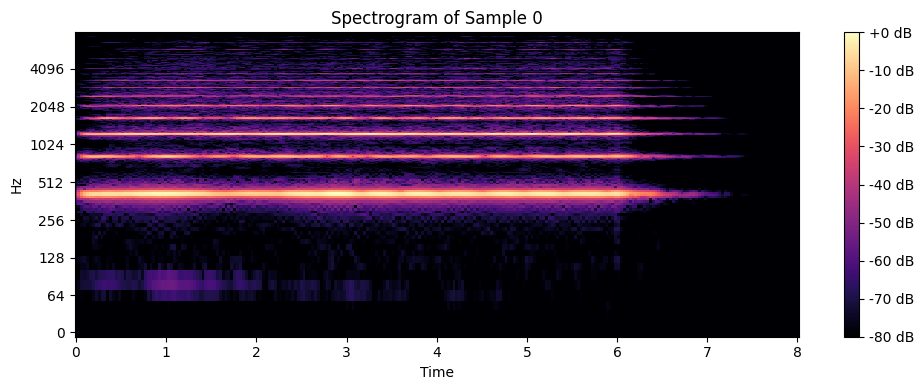

In [5]:
import soundfile as sf
plot_spectrogram(audio[0].numpy(), title="Spectrogram of Sample 0")
# sf.write("batch_example.wav", audio.numpy()[0], 16000)

In [6]:
strategy = train_util.get_strategy()

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:CPU:0',)


In [7]:
TIME_STEPS = 1000

# Create Neural Networks.
preprocessor = preprocessing.F0LoudnessPreprocessor(time_steps=TIME_STEPS)

decoder = decoders.RnnFcDecoder(rnn_channels = 256,
                                rnn_type = 'gru',
                                ch = 256,
                                layers_per_stack = 1,
                                input_keys = ('ld_scaled', 'f0_scaled'),
                                output_splits = (('amps', 1),
                                                 ('harmonic_distribution', 45),
                                                 ('noise_magnitudes', 45)))

# Create Processors.
harmonic = ddsp.synths.Harmonic(n_samples=n_samples, 
                                sample_rate=16000,
                                name='harmonic')

noise = ddsp.synths.FilteredNoise(window_size=0,
                                  initial_bias=-10.0,
                                  name='noise')
add = ddsp.processors.Add(name='add')

# Create ProcessorGroup.
dag = [(harmonic, ['amps', 'harmonic_distribution', 'f0_hz']),
       (noise, ['noise_magnitudes']),
       (add, ['noise/signal', 'harmonic/signal'])]

processor_group = ddsp.processors.ProcessorGroup(dag=dag,
                                                 name='processor_group')


# Loss_functions
spectral_loss = ddsp.losses.SpectralLoss(loss_type='L1',
                                         mag_weight=1.0,
                                         logmag_weight=1.0)

with strategy.scope():
  # Put it together in a model.
  model = models.Autoencoder(preprocessor=preprocessor,
                             encoder=None,
                             decoder=decoder,
                             processor_group=processor_group,
                             losses=[spectral_loss])
  trainer = trainers.Trainer(model, strategy, learning_rate=1e-3)

In [8]:
# Build model, easiest to just run forward pass.
dataset = trainer.distribute_dataset(dataset)
trainer.build(next(iter(dataset)))

2025-05-11 00:21:04.806012: W tensorflow/core/grappler/optimizers/data/auto_shard.cc:549] The `assert_cardinality` transformation is currently not handled by the auto-shard rewrite and will be removed.
2025-05-11 00:21:04.994512: W tensorflow/core/framework/dataset.cc:769] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Model: "autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 f0_loudness_preprocessor (F  multiple                 0         
 0LoudnessPreprocessor)                                          
                                                                 
 rnn_fc_decoder (RnnFcDecode  multiple                 814171    
 r)                                                              
                                                                 
 processor_group (ProcessorG  multiple                 0         
 roup)                                                           
                                                                 
 spectral_loss (SpectralLoss  multiple                 0         
 )                                                               
                                                                 
Total params: 814,171
Trainable params: 814,171
Non-tra

In [9]:
dataset_iter = iter(dataset)

for i in range(100):
  losses = trainer.train_step(dataset_iter)
  res_str = 'step: {}\t'.format(i)
  for k, v in losses.items():
    res_str += '{}: {:.2f}\t'.format(k, v)
  print(res_str)

2025-05-11 00:23:18.690092: W tensorflow/core/framework/dataset.cc:769] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


step: 0	spectral_loss: 24.11	total_loss: 24.11	
step: 1	spectral_loss: 24.89	total_loss: 24.89	
step: 2	spectral_loss: 29.25	total_loss: 29.25	
step: 3	spectral_loss: 28.35	total_loss: 28.35	
step: 4	spectral_loss: 24.59	total_loss: 24.59	
step: 5	spectral_loss: 16.27	total_loss: 16.27	
step: 6	spectral_loss: 19.21	total_loss: 19.21	
step: 7	spectral_loss: 27.01	total_loss: 27.01	
step: 8	spectral_loss: 39.46	total_loss: 39.46	
step: 9	spectral_loss: 22.37	total_loss: 22.37	
step: 10	spectral_loss: 24.47	total_loss: 24.47	
step: 11	spectral_loss: 18.65	total_loss: 18.65	
step: 12	spectral_loss: 22.08	total_loss: 22.08	
step: 13	spectral_loss: 18.54	total_loss: 18.54	
step: 14	spectral_loss: 34.05	total_loss: 34.05	
step: 15	spectral_loss: 24.41	total_loss: 24.41	
step: 16	spectral_loss: 16.74	total_loss: 16.74	
step: 17	spectral_loss: 23.46	total_loss: 23.46	
step: 18	spectral_loss: 29.35	total_loss: 29.35	
step: 19	spectral_loss: 19.81	total_loss: 19.81	
step: 20	spectral_loss: 15.50	

In [10]:
# Run a batch of predictions.
start_time = time.time()
controls =  model(next(dataset_iter))
audio_gen = model.get_audio_from_outputs(controls)
print('Prediction took %.1f seconds' % (time.time() - start_time))

Prediction took 2.4 seconds


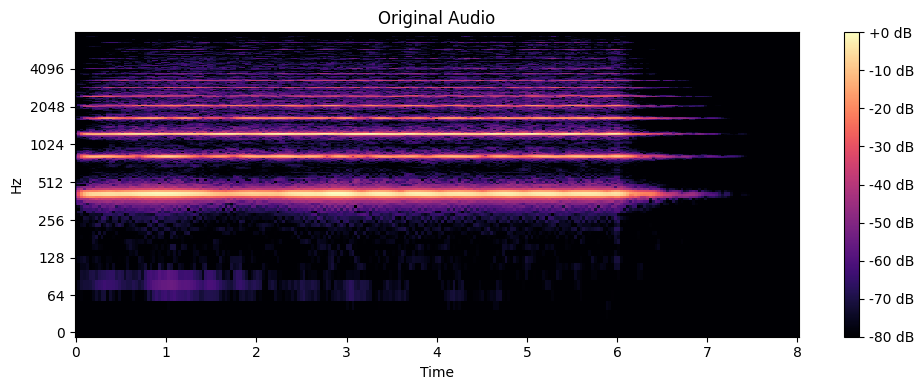

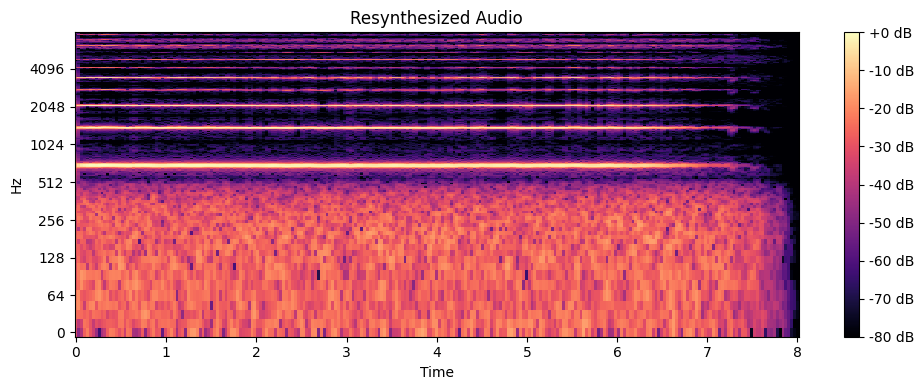

In [11]:
# Save audio to current directory
sf.write("original.wav", audio.numpy()[0], 16000)
sf.write("resynthesized.wav", audio_gen.numpy()[0], 16000)

plot_spectrogram(audio.numpy()[0], "Original Audio")
plot_spectrogram(audio_gen.numpy()[0], "Resynthesized Audio")

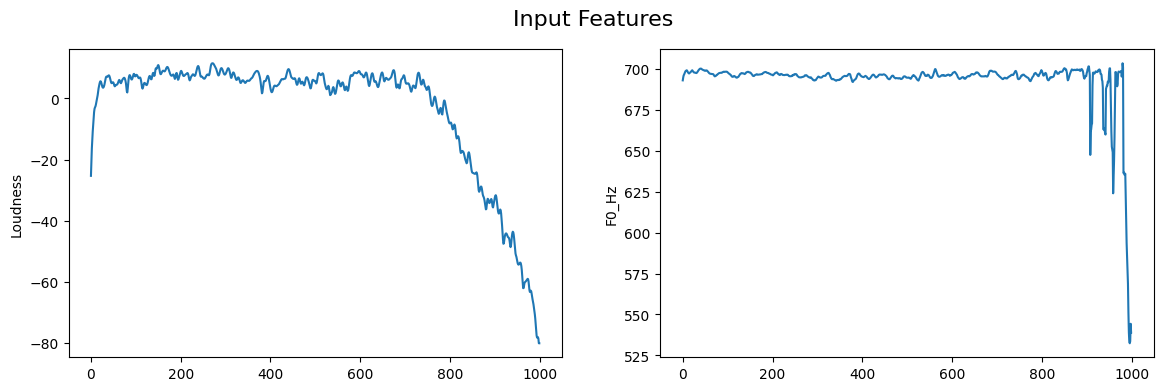

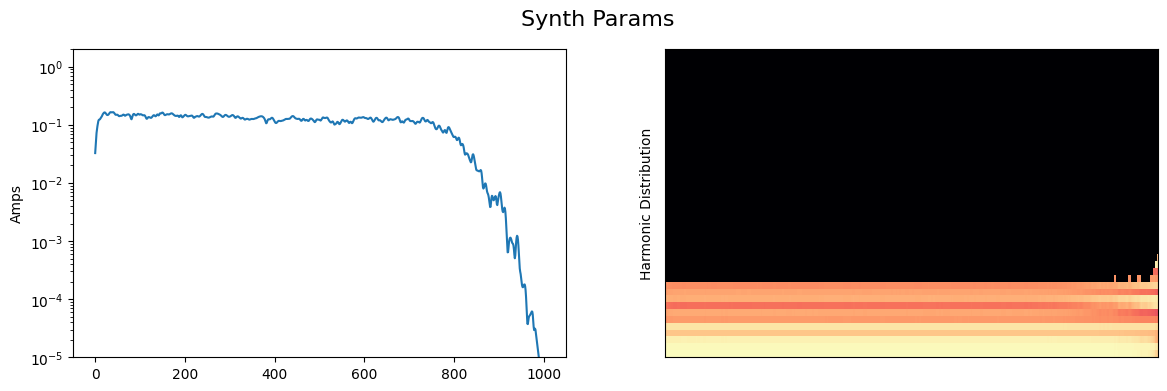

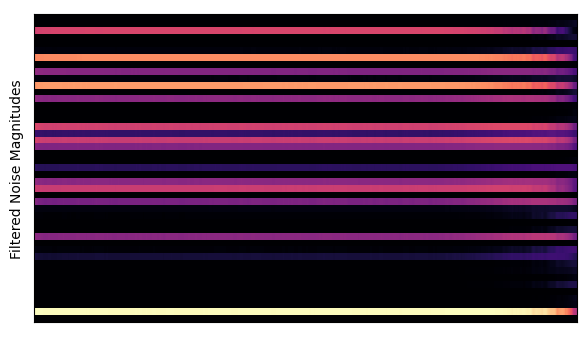

In [12]:
batch_idx = 0
get = lambda key: ddsp.core.nested_lookup(key, controls)[batch_idx]

amps = get('harmonic/controls/amplitudes')
harmonic_distribution = get('harmonic/controls/harmonic_distribution')
noise_magnitudes = get('noise/controls/magnitudes')
f0_hz = get('f0_hz')
loudness = get('loudness_db')

audio_noise = get('noise/signal')

f, ax = plt.subplots(1, 2, figsize=(14, 4))
f.suptitle('Input Features', fontsize=16)
ax[0].plot(loudness)
ax[0].set_ylabel('Loudness')
ax[1].plot(f0_hz)
ax[1].set_ylabel('F0_Hz')

f, ax = plt.subplots(1, 2, figsize=(14, 4))
f.suptitle('Synth Params', fontsize=16)
ax[0].semilogy(amps)
ax[0].set_ylabel('Amps')
ax[0].set_ylim(1e-5, 2)
# ax[0].semilogy(harmonic_distribution)
ax[1].matshow(np.rot90(np.log10(harmonic_distribution + 1e-6)),
              cmap=plt.cm.magma, 
              aspect='auto')
ax[1].set_ylabel('Harmonic Distribution')
ax[1].set_xticks([])
_ = ax[1].set_yticks([])

f, ax = plt.subplots(1, 1, figsize=(7, 4))
# f.suptitle('Filtered Noise Params', fontsize=16)
ax.matshow(np.rot90(np.log10(noise_magnitudes + 1e-6)), 
           cmap=plt.cm.magma, 
           aspect='auto')
ax.set_ylabel('Filtered Noise Magnitudes')
ax.set_xticks([])
_ = ax.set_yticks([])

In [33]:
import scipy.linalg

# Performance Analysis Helper Functions:
def mag_spectrogram(y, sr, n_fft=1024, hop_length=256):
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window='hann')
    return np.abs(S)

def log_spectral_distance(y_true, y_pred, sr, n_fft=1024, hop_length=256, eps=1e-8):
    S_true = mag_spectrogram(y_true, sr, n_fft, hop_length)
    S_pred = mag_spectrogram(y_pred, sr, n_fft, hop_length)
    # convert to log10 scale
    L_true = 20 * np.log10(S_true + eps)
    L_pred = 20 * np.log10(S_pred + eps)

    diff2 = (L_true - L_pred) ** 2
    lsd_frames = np.sqrt(np.mean(diff2, axis=0))
    return np.mean(lsd_frames)

def spectral_convergence(y_true, y_pred, sr, n_fft=1024, hop_length=256):
    S_true = mag_spectrogram(y_true, sr, n_fft, hop_length)
    S_pred = mag_spectrogram(y_pred, sr, n_fft, hop_length)
    num = np.linalg.norm(S_true - S_pred, ord='fro')
    den = np.linalg.norm(S_true, ord='fro') + 1e-8
    return num / den

def snr_db(y_true, y_pred, eps=1e-8):
    noise = y_true - y_pred
    power_signal = np.sum(y_true ** 2)
    power_noise  = np.sum(noise ** 2) + eps
    return 10 * np.log10(power_signal / power_noise)

def embed_mel(waveform, sr=16000, n_mels=64, n_fft=1024, hop_length=256):
    S = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=1.0
    )
    return S.T      # shape (T, n_mels)

def compute_statistics(embeddings_list):
    all_embs = np.vstack(embeddings_list)
    mu    = np.mean(all_embs, axis=0)
    sigma = np.cov(all_embs, rowvar=False)
    return mu, sigma

def frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    mu_diff = mu1 - mu2
    covmean, _ = scipy.linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm((sigma1 + offset) @ (sigma2 + offset))
    # drop tiny imaginary parts
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return (mu_diff @ mu_diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

def compute_fad_mel(y_true_list, y_pred_list, sr=16000):
    # allow passing single arrays
    if isinstance(y_true_list, np.ndarray):
        y_true_list = [y_true_list]
    if isinstance(y_pred_list, np.ndarray):
        y_pred_list = [y_pred_list]

    true_embs = [embed_mel(y, sr) for y in y_true_list]
    pred_embs = [embed_mel(y, sr) for y in y_pred_list]
    mu1, sigma1 = compute_statistics(true_embs)
    mu2, sigma2 = compute_statistics(pred_embs)
    return frechet_distance(mu1, sigma1, mu2, sigma2)

In [34]:
y_true = audio.numpy().reshape(-1)
y_pred = audio_gen.numpy().reshape(-1)

# 2. Compute reconstruction-error metrics
lsd_value = log_spectral_distance(y_true, y_pred, sr=16000, n_fft=1024, hop_length=256)
sc_value  = spectral_convergence(y_true, y_pred, sr=16000, n_fft=1024, hop_length=256)
snr_value = snr_db(y_true, y_pred)
fad_score = compute_fad_mel(y_true, y_pred, sr=16000)


# 3. Print
print("PERFORMANCE METRICS")
print("==========================================================\n")
print(f"Log-Spectral Distance (LSD):      {lsd_value:.3f} dB")
print(f"Spectral Convergence:             {sc_value:.5f}")
print(f"Signal-to-Noise Ratio (SNR):      {snr_value:.2f} dB")
print(f"Frechet Audio Distance (FAD):     {fad_score:.4f}")
print("==========================================================\n")

PERFORMANCE METRICS

Log-Spectral Distance (LSD):      30.052 dB
Spectral Convergence:             1.00443
Signal-to-Noise Ratio (SNR):      -0.12 dB
Frechet Audio Distance (FAD):     6.2396



In [36]:
trainer.save("./reconstruction_checkpoint")